<a href="https://colab.research.google.com/github/RafaellsAlmeida/RafaellsAlmeida/blob/main/LoureiroSandimdeAlmeida_Rafael_Week05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- ISM4543-BANNER -->
# Integrative Assignment on Week 05 Material — QuickLend Financial
## Logistic regression for credit risk

**ISM4543 | Applied Data Science | Fall 2026**

| | |
|---|---|
| **Due** | Monday, September 28, 2026, 11:59 PM |
| **Points** | 100, allocated by the six rubric components in the syllabus — Problem Framing 10, Technical Implementation 25, Verification Trail 15, Understanding 25, AI Usage Report 10, Critical Analysis 15. The Parts below are the shape of the work, not separate mark pots. |
| **Submit** | Three deliverables: this notebook (`.ipynb`), your **AI Usage Report** (the full Gemini conversation export *plus* your written account of it), and a **3–5 minute video walkthrough** (hard stop at five minutes). Submit the video as a **file upload on the Canvas assignment** or a **publicly accessible link in the Canvas submission comment** — never embedded in this notebook. **No video, or a link we cannot open, is −15 points.** The reflection section below is part of the notebook. |
| **AI policy** | AI assistance is **expected**, and documenting it is **required**. Explanations and reflections must be **your own words**. |
| **Late work** | 20% deduction up to 24 hours late. **After 24 hours, no credit.** |
| **Grade questions** | Raise any grading issue within **5 days** of the evaluation being posted. After that the evaluation stands. |

> **Why "integrative"?** This assignment does not test this week's technique in
> isolation. It expects you to bring forward the data preparation, evaluation, and
> communication skills from earlier weeks and combine them with what you learned
> this week. Marks are lost for a technically correct model presented without
> framing, verification, or interpretation.

---


## The client: QuickLend Financial

**QuickLend Financial** is an online lender that approves or declines small personal loans in
minutes. Over the past two years it has issued **2,000 loans**, and it knows how each one turned
out: repaid, or defaulted. Today's approve-or-decline rule is a **credit-score cutoff** inherited
from a previous head of risk, and nobody remembers how the cutoff was chosen. Last year it was
lowered by twenty points to grow the book; volume rose, and so did losses, and nobody has separated
the two effects. Three people want answers from those 2,000 loans.

- **David Kim, Chief Risk Officer:** *"Our default rate is climbing. I want a model that flags
  high-risk applications before we approve them, so we can decline them or ask for collateral. Each
  default costs us about \$15,000 in lost principal and collection costs."*
- **Priya Sharma, VP of Lending:** *"But we can't be too conservative. Every good loan we turn away
  is lost revenue, about \$3,000 in interest over the life of the loan. We need to balance risk with
  growth, and I won't sign off on a model that just rejects everybody."*
- **Tom Nguyen, CEO:** *"The board wants to understand the risk model, not just trust a black box.
  Show me which factors drive default, and how much each one matters."*

The decision the model feeds is made **at application time**, on every application: approve,
decline, or require collateral. A model that estimates each applicant's probability of default is
half the job. The other half is choosing **where to set the threshold** that turns that probability
into a decision, and that choice comes from what each kind of mistake costs, not from habit.


### The questions you will answer

| # | Question | Asked by | Worked out in | Answered in |
|---|---|---|---|---|
| 1 | What does each kind of mistake cost QuickLend, and which metric follows from those costs? | David and Priya | Part 1 | 1.2, 1.3 |
| 2 | How common is default, and which applicant features separate the defaulters from the rest? | David | Part 2 | 2.2 |
| 3 | At the default 0.5 cutoff, what does the model get right and wrong, in loans and in dollars? | David | Parts 3 to 5 | 4.1, 4.2, 5.1 |
| 4 | Precision or recall: whose concern wins, and why? | David and Priya | Part 5 | 5.2 |
| 5 | Where should the threshold sit, and how does its cost compare with 0.5's? | David and Priya | Part 6 | 6.2 |
| 6 | What drives default, in plain language, and what should underwriting do about it? | Tom and David | Part 7 | 7.1, 7.2 |

Parts 8 to 10 are about you: three questions answered without AI, two errors to catch, and your
reflection and AI Usage Report.


### About this data

File `loan_default.csv`: **2,000 rows × 13 columns**, one row per loan, no missing values. It loads
by URL in the setup cell. The lender, the people and the decisions are the setting; the loans are
**simulated**, so the data is clean and the patterns are there to be found.

| Column | Meaning |
|---|---|
| `annual_income` | Applicant's stated annual income, dollars (\$25,000 to \$200,000) |
| `loan_amount` | Amount requested, dollars (\$1,617 to \$50,000) |
| `credit_score` | Credit bureau score at application (425 to 850) |
| `employment_years` | Years in current employment (0 to 35) |
| `debt_to_income` | Monthly debt payments divided by monthly income, as a fraction (0.28 means 28%) |
| `num_credit_lines` | Open credit accounts (0 to 14) |
| `previous_defaults` | 1 if the applicant has defaulted on a loan before, 0 if not |
| `purpose_consolidation`, `purpose_home`, `purpose_business` | Loan purpose, one-hot encoded; all three 0 means some other purpose |
| `ownership_own`, `ownership_mortgage` | Home ownership, one-hot encoded; both 0 means the applicant rents |
| `defaulted` | 1 if the loan defaulted, 0 if it was repaid (**the target**) |


### How the work flows

Frame the problem from the costs (Part 1) before you look at the data (Part 2). Split first, then
build one `Pipeline` that scales and fits (Part 3). Read the confusion matrix in loans and dollars
(Part 4) before you read the metrics (Part 5). Choose the threshold on the **training rows** from
what the mistakes cost, and score it **once** on the test set (Part 6). Turn the coefficients into
odds ratios that David and Tom can act on (Part 7). Parts 8 to 10 are written in your own words,
and Part 8 without AI.

### Video walkthrough (required)

Record a 3–5 minute video in your own running notebook, presenting to David Kim and Priya Sharma.
What it must show is listed under **Video walkthrough** at the end of this notebook.

### Instructions

- Use AI for the code; write every interpretation in your own words.
- Follow this week's classification workflow from the slides and the lecture notes. Nothing later
  in the course is needed; if you find yourself reaching for something we have not covered, you
  have overcomplicated it.
- Every decision refers back to QuickLend's costs and people above.
- Part 8 is completed without AI.


---

## Setup

Run this cell first. Every dataset in this course lives in the public course data repo, and every
notebook loads it straight from there.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    fbeta_score
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Framing

### 1.1 Problem Statement

Write a 3-5 sentence problem statement. What are we predicting? Why does it matter? What metric will define success?

Like every loan model, we are optimizing neither for precision, recall, F1 or accuracy. The one metric we are optimizing for, is **money**. The loan default model has been untouched for years, the the CRO, CEO and VP of Landing are discussing the potential harms of False Positives and False Negatives. We will need to look at the data, determine the threshold that allows for the most money made, with the least amount of risk in the long run.


### 1.2 Cost Analysis

Based on the stakeholder quotes, define the cost of each error type:
- **False Positive** (model predicts default, but loan would have been repaid): What is the business cost?

The business cost would be to not gain ~3,000 dollars on average, upset/lose a customer, and stop expanding, potentially losing referrals and bad word of mouth, and client lending from a competitor.

- **False Negative** (model predicts repayment, but loan defaults): What is the business cost?

$15,000 in lost principal, collection costs, management time spent.


Which error is more costly? What does this imply for your metric choice?

The False Negative cost is more costly, so the metric of choise would be recall. A highly precise model could still cost us more.



### 1.3 Success Metric

Based on your cost analysis, which metric (precision, recall, F1, F2, F0.5) is most appropriate? Justify your choice.

Recall. Although it's not good for business, we can allow for up to 5 FPs to 1 FN costing us the same. We will optimize for higher recall so we get as few loan defaults as possible.


---

## Part 2: Data Understanding

In [2]:
# Load loan default dataset from course GitHub repo
DATA_URL = 'https://raw.githubusercontent.com/prof-tcsmith/4543Fall26-DATA/main/data/week05'

df = pd.read_csv(f'{DATA_URL}/loan_default.csv')

print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['defaulted'].mean():.1%}")
df.head()

Dataset shape: (2000, 13)
Default rate: 26.9%


,annual_income,loan_amount,credit_score,employment_years,debt_to_income,num_credit_lines,previous_defaults,purpose_consolidation,purpose_home,purpose_business,ownership_own,ownership_mortgage,defaulted
0,62841.0,6600.0,610,2.5,0.278,7,1,0,1,0,1,0,1
1,45746.0,9075.0,677,1.4,0.184,5,0,1,0,0,0,1,0
2,67768.0,6152.0,681,2.3,0.098,3,0,0,0,0,0,1,0
3,104979.0,8227.0,717,1.2,0.068,3,0,0,0,0,0,0,0
4,43605.0,3177.0,570,13.9,0.175,3,1,1,0,0,0,1,1


### 2.1 EDA for Classification

Explore the data with a classification lens. Address these questions:
1. Is the dataset balanced? What does the default rate mean for accuracy as a measure?
2. Which features show the strongest separation between defaulters and non-defaulters?
3. Are any features highly correlated with the target?

*Use AI to help you write the EDA code, but interpret the results yourself.*

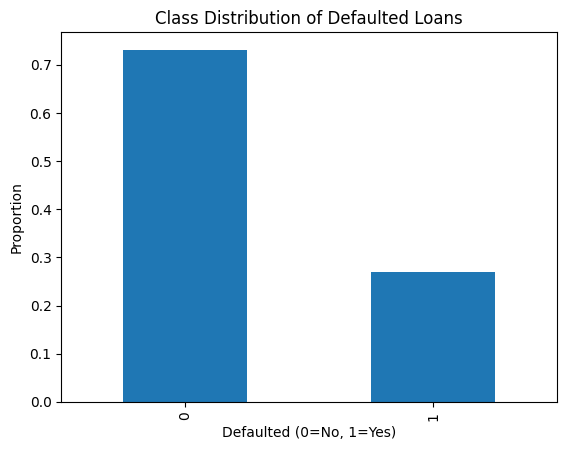

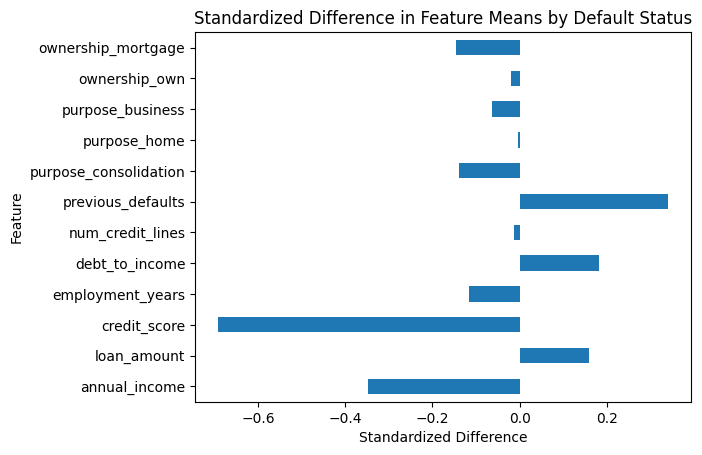

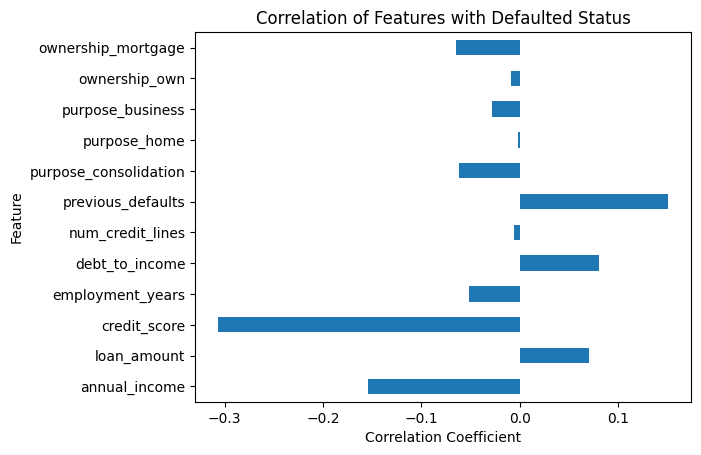

In [5]:
# TODO: Check class distribution.
df['defaulted'].value_counts(normalize=True).plot(kind='bar')
plt.title('Class Distribution of Defaulted Loans')
plt.xlabel('Defaulted (0=No, 1=Yes)')
plt.ylabel('Proportion')
plt.show()

# TODO: Compare feature means by class
features = df.columns.drop('defaulted')
means = df.groupby('defaulted')[features].mean()
diff = (means.loc[1] - means.loc[0]) / df[features].std()
diff.plot(kind='barh')
plt.title('Standardized Difference in Feature Means by Default Status')
plt.xlabel('Standardized Difference')
plt.ylabel('Feature')
plt.show()


# TODO: Correlation with target
orr = df[features].corrwith(df['defaulted'])
orr.plot(kind='barh')
plt.title('Correlation of Features with Defaulted Status')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

### 2.2 EDA Summary

Summarize your key findings from the EDA. Which features look most predictive? Are there any concerns about the data?

Previous defaults look the most predicted on impacting defaults, while a high credit score strongly predict repayments.


---

## Part 3: Data Preparation

### 3.1 Feature Selection and Splitting

Select your features, define the target, and split with `stratify`.

In [7]:
# TODO: Define feature_cols and target
# Create the proper features except for defaulted, purpose_home, ownership_own and num_creditlines
features = df.columns.drop('defaulted')
target = 'defaulted'

X = df[features]
y = df[target]

# TODO: Split with stratify=y, test_size=0.2, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TODO: Verify class proportions are preserved
print('Original target distribution:')
print(y.value_counts(normalize=True))
print('\nTraining set target distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest set target distribution:')
print(y_test.value_counts(normalize=True))

Original target distribution:
defaulted
0    0.731
1    0.269
Name: proportion, dtype: float64

Training set target distribution:
defaulted
0    0.73125
1    0.26875
Name: proportion, dtype: float64

Test set target distribution:
defaulted
0    0.73
1    0.27
Name: proportion, dtype: float64


### 3.2 Pipeline Construction

Build a Pipeline with `StandardScaler` and `LogisticRegression(class_weight='balanced')`, as the deck does. In one sentence, say what `'balanced'` does with this dataset's default rate.

In [9]:
# TODO: Build and fit Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])

pipe.fit(X_train, y_train)
# TODO: Generate y_pred and y_proba

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

*Your one sentence — what `'balanced'` does with this dataset's default rate:*

It penalizes for the class 1 mistakes, weighting each class by the inverse of its share. One Class 1 mistake would cost 2.7 times more, so the model doesn't ignore our loan defaults.  


---

## Part 4: Confusion Matrix and Cost Analysis

### 4.1 Confusion Matrix

Generate the confusion matrix, display it visually, and compute metrics by hand from the TP/FP/TN/FN values.

Confusion Matrix Values:
  True Negatives (Actual Repayment, Predicted Repayment): 204
  False Positives (Actual Repayment, Predicted Default): 88
  False Negatives (Actual Default, Predicted Repayment): 29
  True Positives (Actual Default, Predicted Default): 79


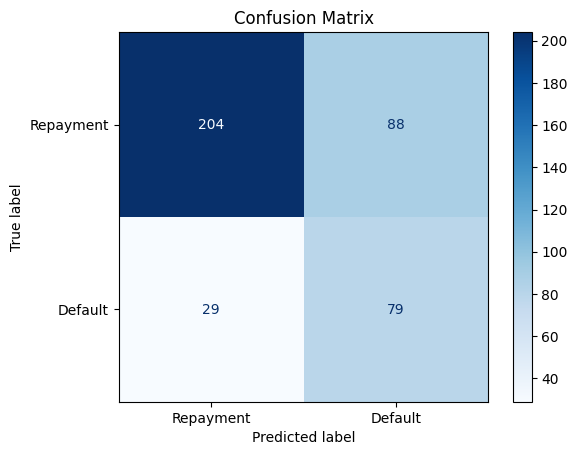


Precision (for Default class): 0.4731
Recall (for Default class): 0.7315
Accuracy: 0.7075
F1 Score (for Default class): 0.5745


In [15]:
# TODO: Compute confusion matrix, extract tn, fp, fn, tp
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Values:\n  True Negatives (Actual Repayment, Predicted Repayment): {tn}\n  False Positives (Actual Repayment, Predicted Default): {fp}\n  False Negatives (Actual Default, Predicted Repayment): {fn}\n  True Positives (Actual Default, Predicted Default): {tp}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Repayment', 'Default'],
    cmap='Blues',
    values_format='d' # Added to display numbers in the matrix
)
plt.title('Confusion Matrix')
plt.show()

# TODO: Print values with business labels

# Manually compute precision, recall, accuracy, F1 from the values

# Precision (for Default class = 1)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"\nPrecision (for Default class): {precision:.4f}")

# Recall (for Default class = 1)
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Recall (for Default class): {recall:.4f}")

# Accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")

# F1 Score (for Default class = 1)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1 Score (for Default class): {f1_score:.4f}")

### Interpreting the Confusion Matrix Plot

The confusion matrix visually breaks down your model's predictions:

-   **Rows** represent the **Actual** (True) labels.
-   **Columns** represent the **Predicted** labels.

Based on the plot with `display_labels=['Repayment', 'Default']`:

-   **Top-Left (Actual: Repayment, Predicted: Repayment):** This is where your **True Negatives (TN)** are located. These are the loans that were correctly predicted as 'Repayment'.
-   **Top-Right (Actual: Repayment, Predicted: Default):** This is where your **False Positives (FP)** are located. These are loans that *actually* repaid but were incorrectly predicted as 'Default'. This is the business cost of turning away good loans.
-   **Bottom-Left (Actual: Default, Predicted: Repayment):** This is where your **False Negatives (FN)** are located. These are loans that *actually* defaulted but were incorrectly predicted as 'Repayment'. This is the costly business error of approving a bad loan.
-   **Bottom-Right (Actual: Default, Predicted: Default):** This is where your **True Positives (TP)** are located. These are the loans that were correctly predicted as 'Default'.

The numbers in each cell of the plot correspond to the `tn`, `fp`, `fn`, `tp` values that were printed just above the plot. For example, your `tn` value (204) is in the top-left cell, and your `tp` value (79) is in the bottom-right cell.

### 4.2 Cost-Sensitive Evaluation

Using the costs from Part 1.2, calculate the total business cost of the model's errors at the default threshold.

*Show the calculation clearly.*

In [14]:
# TODO: Define COST_FP and COST_FN (dollars per error) from your Part 1.2 analysis
COST_FP = 3000  # Cost of a False Positive (lost revenue from good loan turned away)
COST_FN = 15000 # Cost of a False Negative (lost principal and collection costs from default)

# Extract tn, fp, fn, tp from the confusion matrix (assuming cm is already calculated from the previous cell)
# If cm was not global, we would need to recompute or pass it.
# For this context, assuming tn, fp, fn, tp are available from the previous run of 957ab3fe.

# TODO: Calculate total_cost
total_cost = (fp * COST_FP) + (fn * COST_FN)

# TODO: Print breakdown
print(f"Business Cost Breakdown at default threshold (0.5):")
print(f"  False Positives (FP): {fp} loans * ${COST_FP}/loan = ${fp * COST_FP}")
print(f"  False Negatives (FN): {fn} loans * ${COST_FN}/loan = ${fn * COST_FN}")
print(f"Total Business Cost: ${total_cost}")

Business Cost Breakdown at default threshold (0.5):
  False Positives (FP): 88 loans * $3000/loan = $264000
  False Negatives (FN): 29 loans * $15000/loan = $435000
Total Business Cost: $699000


---

## Part 5: Classification Metrics

### 5.1 Classification Report

Generate and interpret the full classification report. Focus on the row for class 1, the defaulted loans (it is labelled `1` unless you pass `target_names`).

*What does each number in that row mean for QuickLend's business?*

In [16]:
# TODO: Print classification_report
print(classification_report(y_test, y_pred, target_names=['Repayment', 'Default']))

              precision    recall  f1-score   support

   Repayment       0.88      0.70      0.78       292
     Default       0.47      0.73      0.57       108

    accuracy                           0.71       400
   macro avg       0.67      0.72      0.68       400
weighted avg       0.77      0.71      0.72       400



*Your interpretation:*

Out of the repayments flagged, 88% were right. Out of the real repayments, the model catched 70.

Out of the defaults flagged, only 47% were right, but of the total real defaults you catched 73% of those.

Alghouth the 47% precision is scary since we lost multiple potential loans, we still protected the real defaults (5x more costly) by catching 73% of the defaults.


### 5.2 Precision vs Recall Decision

Given QuickLend's business context, should the model prioritize precision or recall? Reference the specific stakeholder needs (David Kim wants safety, Priya Sharma wants growth).

Recall, since we our defaults are more costly than missing a loan.


---

## Part 6: Threshold Optimization

### 6.1 Threshold Comparison

Compare model performance at thresholds 0.3, 0.5, and 0.7 **on the test set** (`y_proba`). For each, show the number of flagged loans, precision, recall, and business cost. This table *describes* the model at three fixed cutoffs; it is not how you choose one — 6.2 chooses on the training rows.

In [17]:
# Define thresholds to evaluate
thresholds = [0.3, 0.5, 0.7]

# Define costs
COST_FP = 3000
COST_FN = 15000

print(f"{'Threshold':<10} | {'Flagged':<7} | {'Precision':<9} | {'Recall':<6} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Business Cost':<13}")
print("-" * 82)

for thresh in thresholds:
    # Predict class based on custom threshold
    preds = (y_proba >= thresh).astype(int)

    # Compute confusion matrix components
    cm_thresh = confusion_matrix(y_test, preds, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()

    # Calculate metrics
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    cost_t = (fp_t * COST_FP) + (fn_t * COST_FN)
    flagged = tp_t + fp_t

    print(f"{thresh:<10.1f} | {flagged:<7} | {prec_t:<9.4f} | {rec_t:<6.4f} | {tn_t:<5} | {fp_t:<5} | {fn_t:<5} | {tp_t:<5} | ${cost_t:,.2f}")

Threshold  | Flagged | Precision | Recall | TN    | FP    | FN    | TP    | Business Cost
----------------------------------------------------------------------------------
0.3        | 286     | 0.3497    | 0.9259 | 106   | 186   | 8     | 100   | $678,000.00
0.5        | 167     | 0.4731    | 0.7315 | 204   | 88    | 29    | 79    | $699,000.00
0.7        | 72      | 0.5833    | 0.3889 | 262   | 30    | 66    | 42    | $1,080,000.00


### 6.2 Cost-Optimal Threshold

Sweep thresholds from 0.05 to 0.95 in steps of 0.01 on the **training rows**
(`pipe.predict_proba(X_train)`) to find the cost-optimal one, as the deck's *Cost-Based Threshold
Optimization* slide does, and plot the cost curve. Then score your chosen threshold **once** on the
test set.

*How does its test-set cost compare with the default 0.5's, and is the difference big enough to act
on?*

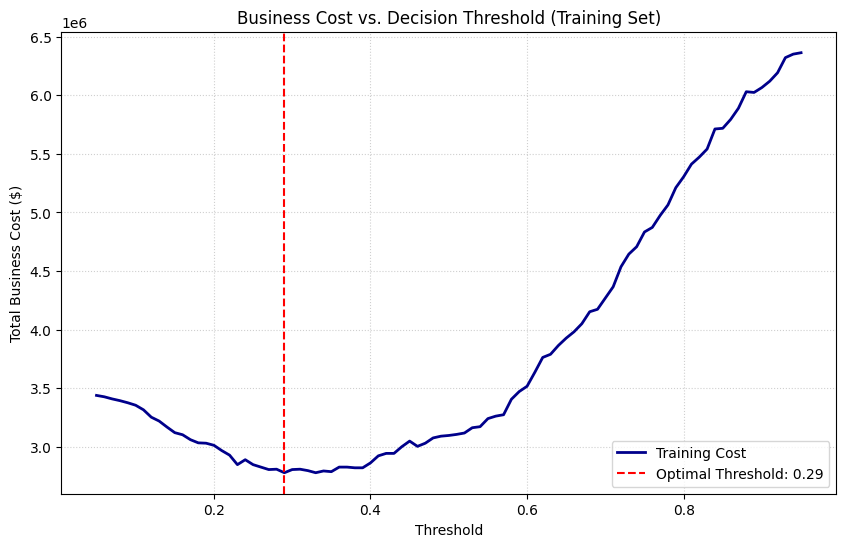

Optimal Threshold determined from Training set: 0.29 (Training Cost: $2,778,000.00)

--- Test Set Performance Comparison ---
Standard Cutoff (0.5) Test Cost: $699,000.00  (FPs: 88, FNs: 29)
Optimal Cutoff (0.29) Test Cost: $693,000.00 (FPs: 191, FNs: 8)
Net Savings on Test Set: $6,000.00


In [18]:
# Get predicted probabilities on the TRAINING set
y_train_proba = pipe.predict_proba(X_train)[:, 1]

# Define thresholds to sweep (0.05 to 0.95 in steps of 0.01)
sweep_thresholds = np.arange(0.05, 0.96, 0.01)
training_costs = []

# Cost parameters
COST_FP = 3000
COST_FN = 15000

# Sweep on training data
for thresh in sweep_thresholds:
    preds_train = (y_train_proba >= thresh).astype(int)
    cm_train = confusion_matrix(y_train, preds_train, labels=[0, 1])
    _, fp_train, fn_train, _ = cm_train.ravel()
    cost_train = (fp_train * COST_FP) + (fn_train * COST_FN)
    training_costs.append(cost_train)

# Find the training optimal threshold
opt_idx = np.argmin(training_costs)
optimal_threshold = sweep_thresholds[opt_idx]
min_training_cost = training_costs[opt_idx]

# Plot the training cost curve
plt.figure(figsize=(10, 6))
plt.plot(sweep_thresholds, training_costs, label='Training Cost', color='darkblue', lw=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.title('Business Cost vs. Decision Threshold (Training Set)')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Optimal Threshold determined from Training set: {optimal_threshold:.2f} (Training Cost: ${min_training_cost:,.2f})")

# --- Score once on the TEST set ---
# Standard 0.5 test evaluation
test_preds_50 = (y_proba >= 0.5).astype(int)
tn_50, fp_50, fn_50, tp_50 = confusion_matrix(y_test, test_preds_50, labels=[0, 1]).ravel()
test_cost_50 = (fp_50 * COST_FP) + (fn_50 * COST_FN)

# Custom optimal threshold test evaluation
test_preds_opt = (y_proba >= optimal_threshold).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, test_preds_opt, labels=[0, 1]).ravel()
test_cost_opt = (fp_opt * COST_FP) + (fn_opt * COST_FN)

print("\n--- Test Set Performance Comparison ---")
print(f"Standard Cutoff (0.5) Test Cost: ${test_cost_50:,.2f}  (FPs: {fp_50}, FNs: {fn_50})")
print(f"Optimal Cutoff ({optimal_threshold:.2f}) Test Cost: ${test_cost_opt:,.2f} (FPs: {fp_opt}, FNs: {fn_opt})")
print(f"Net Savings on Test Set: ${test_cost_50 - test_cost_opt:,.2f}")

*Your analysis of the optimal threshold:*

The optimal threshold takes into the consideration our actual computed cost of the False Negative vs False Positive, and setting the threshold at .29 gives us the lowest average cost of failures.

In my opinion, there could be bigger value at .38 since there are a lot of unseen benefits from accepting loans, such as potential referrals, upsells, cross sells, and other opportunities by getting more customers, but that's a balance for the C-suite to decide

---

## Part 7: Feature Importance & Business Recommendations

### 7.1 Coefficients and Odds Ratios

Extract coefficients from the Pipeline and calculate odds ratios. Add each feature's
standard deviation on the training rows (`X_train.std()`), so you can say what one standard deviation
is in the feature's own units.

In [19]:
# Extract model from pipeline
model = pipe.named_steps['model']
feature_names = X_train.columns

# Create coefficient + odds ratio table with each feature's training SD
coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0]),
    'Training SD': X_train[feature_names].std().values
}).sort_values('Coefficient', key=abs, ascending=False)

coefs

,Feature,Coefficient,Odds Ratio,Training SD
2,credit_score,-0.811536,0.444175,78.877561
0,annual_income,-0.554916,0.574121,28951.140267
6,previous_defaults,0.372265,1.451018,0.360822
9,purpose_business,-0.268672,0.764394,0.360221
7,purpose_consolidation,-0.266043,0.766406,0.492984
4,debt_to_income,0.251075,1.285406,0.092817
1,loan_amount,0.205523,1.228167,7457.880075
8,purpose_home,-0.188128,0.828508,0.400593
11,ownership_mortgage,-0.159654,0.852438,0.490051
3,employment_years,-0.150164,0.860567,5.529702


### 7.2 Business Recommendations

To: **David Kim, Chief Risk Officer**  
From: Underwriting Analytics Team  

Based on our trained predictive model, we recommend that the underwriting team focus closely on the following key risk indicators. Because the model analyzed these factors in terms of standard deviations, we have translated them here into actual business units:

1.  **Prioritize Credit Score Checks (Strongest Negative Driver):**
    *   **The Fact:** A one-standard-deviation increase in Credit Score (**approx. 79 points**) reduces the odds of default by **55.6%** (Odds Ratio: 0.44).
    *   **Action:** Ensure our automated rules heavily reward credit scores above our average of ~690. Every ~79-point increase dramatically stabilizes the portfolio.

2.  **Mitigate Exposure to High Annual Incomes (Strong Negative Driver):**
    *   **The Fact:** A one-standard-deviation increase in Annual Income (**approx. $28,951**) reduces default odds by **42.6%** (Odds Ratio: 0.57).
    *   **Action:** Verify income strictly, as higher income strongly insulates applicants against default risk.

3.  **Flag Applicants with Previous Defaults (Strongest Positive Driver):**
    *   **The Fact:** Having a history of a previous default increases the odds of defaulting on a new loan by **45.1%** (Odds Ratio: 1.45).
    *   **Action:** Underwriting should apply automatic conditional approvals (like requiring physical collateral) or implement a lower loan-to-value ceiling for any applicant with a flagged `previous_defaults` value of 1.

4.  **Monitor Debt-to-Income (DTI) Ratios (Positive Driver):**
    *   **The Fact:** A one-standard-deviation increase in DTI (**approx. 9.3%**) increases default odds by **28.5%** (Odds Ratio: 1.29).
    *   **Action:** Establish strict manual review thresholds when an applicant's DTI pushes past typical levels, as high recurring monthly debt relative to monthly income severely strains repayment capacity.

---

## Part 8: Understanding Demonstration

**Answer these questions WITHOUT AI assistance.** These test your conceptual understanding of the material from the slides and lecture notes.

**Q1:** Why is a Pipeline necessary for this analysis? What would go wrong if you scaled the data before splitting?

Without it scaling we would have trouble turning the metrics into actionable steps, since real world data is spread in (for example) days of the week, miles, liters, credit scores, purpose_business, and we need to scale the features properly so we understand each feature's measureable impact in the prediction



**Q2:** David Kim asks about a vendor's model: "It has 88% accuracy. Is that good?" About 27% of the loans in the dataset defaulted. Explain to David why accuracy alone doesn't answer his question, and what he should look at instead.

*Your answer:*

Accuracy alone cannot answer whether the model is 'good' for business since we need to take into account the business problem and understand how much a False Negative and a False Positive costs us, and the most costly one needs to be optimized around, like we did in the model: since Defaults cost us 15000, we chose recall as the main metric.

**Q3:** Priya Sharma says: "Just set the threshold to 0.9 so we only reject loans we're really sure will default." What are the consequences of this approach? Use the confusion matrix terminology (TP, FP, FN, TN) in your answer.

*Your answer:*

zthe code belowe shows how the 0.9 threshold would look like in this case: a big loss of 1.5 million dollars. This occurs because this high threshold is optimized for False Positives, which are less costly than false negatives.


In [20]:
# Evaluate threshold of 0.9 on the test set
thresh_90 = 0.9
preds_90 = (y_proba >= thresh_90).astype(int)

# Compute confusion matrix
cm_90 = confusion_matrix(y_test, preds_90, labels=[0, 1])
tn_90, fp_90, fn_90, tp_90 = cm_90.ravel()

# Calculate business cost
cost_90 = (fp_90 * COST_FP) + (fn_90 * COST_FN)

# Calculate metrics
prec_90 = tp_90 / (tp_90 + fp_90) if (tp_90 + fp_90) > 0 else 0
rec_90 = tp_90 / (tp_90 + fn_90) if (tp_90 + fn_90) > 0 else 0

print(f"--- Results at 0.9 Threshold ---")
print(f"True Negatives (TN): {tn_90}")
print(f"False Positives (FP): {fp_90}")
print(f"False Negatives (FN): {fn_90}")
print(f"True Positives (TP): {tp_90}")
print(f"Precision: {prec_90:.4f}")
print(f"Recall: {rec_90:.4f}")
print(f"Total Business Cost: ${cost_90:,.2f}")

--- Results at 0.9 Threshold ---
True Negatives (TN): 290
False Positives (FP): 2
False Negatives (FN): 105
True Positives (TP): 3
Precision: 0.6000
Recall: 0.0278
Total Business Cost: $1,581,000.00


---

## Part 9: Critical Analysis

Identify the error in each scenario and explain what should be done instead.

**Error 1:** After finding an optimal threshold of 0.35, a colleague produces the final predictions with this code:
```python
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
```

*How should the custom threshold be applied instead?*

*Your answer:*

My colleague should product the final predictions with
y_proba = pipe.predict_proba(X_test)[:, 1]


**Error 2:** A colleague interprets an odds ratio of 2.5 for `debt_to_income` (from a Pipeline with StandardScaler) as: "For every 1% increase in debt-to-income ratio, the odds of default increase by 2.5x."

*What's the correct interpretation?*

The correct interpratation is per 1 standard deviation in debt_to_income, we get 2.5x increase in odds of defaulting


---

## Part 10: Reflection and AI Usage Report

Answer these in **your own words**. AI-generated reflections receive zero credit —
they are easy to spot, because they are fluent and say nothing specific.



### 10.1 Prompt evolution log

Show how at least one of your prompts evolved. What did you ask first, what was
wrong with what you got back, **how did you detect that it was wrong**, and how did
you fix the prompt?



This time I worked more with the code directly from the lecture slides than using Gemini. I have a deeper understanding of the course and its contents, and barely used it. When I needed to do a repetitive task, or implement a code with the column names, it performed perfectly.


*Your log here:*

### 10.2 Confidence self-assessment

Rate 1 (lost) to 5 (could teach it), and be honest — this is not graded on the
number, it is graded on whether the reflection that follows is candid.

| Topic | 1-5 | What would move this up one point? |
|---|---|---|
| Confusion Matrix | 4 | Tools to memorize better what recall and precision mean in the real world. the lecture examples solidified that in my brain. |

### 10.3 AI Usage Report

**Required.** Name every AI tool you used, what you used each one for, and attach
the full conversation export as a separate file. Then account for the work: which
outputs you accepted as-is, which you checked and how, which you corrected, and
which you rejected outright. Include **one thing the AI got wrong that you caught**,
and what you had to know to catch it. "I used Gemini for the code" is not a report.

*Your report here:*

---

## Video walkthrough

**5–7 minutes, hard stop at five.** Record it in **your own running notebook**, and show:

1. **the cost of each kind of error** (1.2) and the metric it led you to choose (1.3);
2. **your cost curve** from the training rows, the threshold you chose, and how its cost compared
   with 0.5's when you scored it **once on the test set** (6.2);
3. **one odds ratio** (7.1) in plain language, including what one standard deviation of that
   feature is in its own units;
4. **one recommendation** for David Kim, with a dollar figure.

Talk the way you would explain it to a colleague; do not read a script. Graders compare the video with
the plots in your notebook.

---

## Before you submit

- [ ] **Kernel -> Restart & Run All**, top to bottom, with no errors. Save the file *after* it has
      run, so your outputs are in what you upload.
- [ ] Every *Your answer* prompt is filled in, in **your own words** — Part 8 without AI.
- [ ] Your **AI Usage Report** is complete -- the prompting, the results, the checking, the
      re-prompting, and one thing you rejected -- **plus the full conversation export attached as a
      separate file.** The written account alone does not satisfy it.
- [ ] File named **`LastName_FirstName_Week05.ipynb`**.
- [ ] Video recorded and submitted -- **file upload on the Canvas assignment, or a publicly
      accessible link in the Canvas submission comment**. Not in this notebook. Test the link signed
      out: no video, or a link we cannot open, is **-15 points**.